<a href="https://colab.research.google.com/github/vaibhavjiyer87/engine-nvh-deep-learning/blob/main/notebooks/02_preprocessing_specification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The notebook is to answer four questions:

1. Are 0.5-, 1.0-, or 2.0-second windows most appropriate?
2. Can the stereo audio safely be converted to mono?
3. Is 16 kHz sufficient for the intended engine-order range?
4. How should RPM and torque labels be calculated within each window?

In [1]:
# ============================================================
# COMPLETE GITHUB AUTHENTICATION + REPOSITORY RESTORE CELL
# Run this after every fresh Colab runtime
# ============================================================

from google.colab import userdata
from pathlib import Path

import os
import shutil
import subprocess


# ------------------------------------------------------------
# 1. Project settings
# ------------------------------------------------------------

REPOSITORY_NAME = "engine-nvh-deep-learning"

# Colab's temporary working location
REPO_DIR = Path("/content") / REPOSITORY_NAME

print(f"Repository directory: {REPO_DIR}")


# ------------------------------------------------------------
# 2. Load GitHub token from Colab Secrets
# ------------------------------------------------------------

github_token = userdata.get("GITHUB_TOKEN")

if not github_token:
    raise ValueError(
        "GITHUB_TOKEN was not found.\n"
        "Open Colab Secrets, add GITHUB_TOKEN, and enable "
        "Notebook access."
    )

# GitHub CLI automatically recognizes GH_TOKEN.
os.environ["GH_TOKEN"] = github_token
os.environ["GH_HOST"] = "github.com"

print("GitHub token loaded from Colab Secrets.")


# ------------------------------------------------------------
# 3. Install GitHub CLI if it is missing
# ------------------------------------------------------------

if shutil.which("gh") is None:
    print("Installing GitHub CLI...")

    subprocess.run(
        ["apt-get", "update", "-qq"],
        check=True,
    )

    subprocess.run(
        ["apt-get", "install", "-y", "-qq", "gh"],
        check=True,
    )

print(
    subprocess.run(
        ["gh", "--version"],
        capture_output=True,
        text=True,
        check=True,
    ).stdout.splitlines()[0]
)


# ------------------------------------------------------------
# 4. Verify authentication and identify GitHub username
# ------------------------------------------------------------

auth_check = subprocess.run(
    [
        "gh",
        "api",
        "user",
        "--jq",
        ".login",
    ],
    capture_output=True,
    text=True,
)

if auth_check.returncode != 0:
    raise RuntimeError(
        "GitHub authentication failed.\n\n"
        f"{auth_check.stderr}"
    )

GITHUB_USERNAME = auth_check.stdout.strip()

print(f"Authenticated GitHub user: {GITHUB_USERNAME}")


# ------------------------------------------------------------
# 5. Configure Git to use GitHub CLI credentials
# ------------------------------------------------------------

subprocess.run(
    [
        "gh",
        "auth",
        "setup-git",
        "--hostname",
        "github.com",
        "--force",
    ],
    check=True,
)

print("Git credential helper configured.")


# ------------------------------------------------------------
# 6. Clone the repository if this is a fresh runtime
# ------------------------------------------------------------

github_repository = (
    f"{GITHUB_USERNAME}/{REPOSITORY_NAME}"
)

if not REPO_DIR.exists():

    print(
        f"Repository is not present in this Colab runtime.\n"
        f"Cloning {github_repository}..."
    )

    subprocess.run(
        [
            "gh",
            "repo",
            "clone",
            github_repository,
            str(REPO_DIR),
        ],
        check=True,
    )

elif not (REPO_DIR / ".git").exists():

    raise RuntimeError(
        f"{REPO_DIR} exists, but it is not a Git repository.\n"
        "Rename or remove that directory before continuing."
    )

else:

    print("Repository already exists in this runtime.")

    # Pull only when there are no uncommitted local changes.
    status_result = subprocess.run(
        [
            "git",
            "-C",
            str(REPO_DIR),
            "status",
            "--porcelain",
        ],
        capture_output=True,
        text=True,
        check=True,
    )

    if status_result.stdout.strip():
        print(
            "Local changes detected. Automatic pull skipped "
            "to avoid overwriting your work."
        )
    else:
        print("Updating repository from GitHub...")

        subprocess.run(
            [
                "git",
                "-C",
                str(REPO_DIR),
                "pull",
                "--ff-only",
            ],
            check=True,
        )


# ------------------------------------------------------------
# 7. Confirm repository and remote
# ------------------------------------------------------------

if not (REPO_DIR / ".git").exists():
    raise RuntimeError(
        f"Repository restoration failed: {REPO_DIR}"
    )

remote_url = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "remote",
        "get-url",
        "origin",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()

current_branch = subprocess.run(
    [
        "git",
        "-C",
        str(REPO_DIR),
        "branch",
        "--show-current",
    ],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()

print("\nGitHub setup completed successfully.")
print(f"Repository: {REPO_DIR}")
print(f"Remote:     {remote_url}")
print(f"Branch:     {current_branch}")


Repository directory: /content/engine-nvh-deep-learning
GitHub token loaded from Colab Secrets.
gh version 2.93.0 (2026-05-27)
Authenticated GitHub user: vaibhavjiyer87
Git credential helper configured.
Repository is not present in this Colab runtime.
Cloning vaibhavjiyer87/engine-nvh-deep-learning...

GitHub setup completed successfully.
Repository: /content/engine-nvh-deep-learning
Remote:     https://github.com/vaibhavjiyer87/engine-nvh-deep-learning.git
Branch:     main


In [2]:
# Session restoration cell

from google.colab import drive
from pathlib import Path
import pandas as pd
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

drive.mount("/content/drive")

# GitHub repository cloned into the current Colab runtime
REPO_DIR = Path("/content/engine-nvh-deep-learning")

if not (REPO_DIR / ".git").exists():
    raise FileNotFoundError(
        f"Git repository not found at:\n{REPO_DIR}\n\n"
        "Run the GitHub authentication and repository-restore cell first."
    )

# Persistent Google Drive project storage
PROJECT_DRIVE = Path(
    "/content/drive/MyDrive/"
    "NVH_DeepLearning/01_EngineOperatingState"
)

RAW_ROOT = (
    PROJECT_DRIVE
    / "data"
    / "raw"
    / "procedural_engine_sounds"
)

AUDIO_DIR = (
    RAW_ROOT
    / "dataset"
    / "audio"
    / "A_full_set"
)

RAW_MANIFEST_PATH = (
    PROJECT_DRIVE
    / "data"
    / "manifests"
    / "raw_file_manifest_v001.csv"
)

raw_manifest = pd.read_csv(RAW_MANIFEST_PATH)

print(f"Repository: {REPO_DIR}")
print(f"Audio directory: {AUDIO_DIR}")
print(f"Manifest rows: {len(raw_manifest)}")

# GitHub location for portfolio-quality preprocessing figures
DESIGN_FIGURE_DIR = (
    REPO_DIR
    / "results"
    / "figures"
    / "preprocessing_design"
)

# GitHub location for compact result tables
DESIGN_TABLE_DIR = (
    REPO_DIR
    / "results"
    / "tables"
)

# Google Drive location for larger intermediate tables
DRIVE_DESIGN_TABLE_DIR = (
    PROJECT_DRIVE
    / "outputs"
    / "tables"
    / "preprocessing_design"
)

# Create directories if they do not already exist
DESIGN_FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DESIGN_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

DRIVE_DESIGN_TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

print("Output directories restored.")
print(f"Figure directory: {DESIGN_FIGURE_DIR}")
print(f"Table directory:  {DESIGN_TABLE_DIR}")
print(f"Drive tables:     {DRIVE_DESIGN_TABLE_DIR}")

Mounted at /content/drive
Repository: /content/engine-nvh-deep-learning
Audio directory: /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/data/raw/procedural_engine_sounds/dataset/audio/A_full_set
Manifest rows: 767
Output directories restored.
Figure directory: /content/engine-nvh-deep-learning/results/figures/preprocessing_design
Table directory:  /content/engine-nvh-deep-learning/results/tables
Drive tables:     /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/outputs/tables/preprocessing_design


In [4]:
# Validating inputs

assert AUDIO_DIR.exists(), f"Audio directory missing: {AUDIO_DIR}"
assert RAW_MANIFEST_PATH.exists(), (
    f"Raw manifest missing: {RAW_MANIFEST_PATH}"
)
assert len(raw_manifest) == 767, (
    f"Expected 767 manifest rows; found {len(raw_manifest)}."
)

print("Input-data validation passed.")

Input-data validation passed.


In [5]:
# Creating output locations

DESIGN_FIGURE_DIR = (
    REPO_DIR
    / "results"
    / "figures"
    / "preprocessing_design"
)

DESIGN_TABLE_DIR = (
    REPO_DIR
    / "results"
    / "tables"
)

DRIVE_DESIGN_TABLE_DIR = (
    PROJECT_DRIVE
    / "outputs"
    / "tables"
    / "preprocessing_design"
)

DESIGN_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
DESIGN_TABLE_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_DESIGN_TABLE_DIR.mkdir(parents=True, exist_ok=True)

In [6]:
# Step 2 — Evaluate candidate window lengths

# Generate window-level candidate statistics
# using the embedded RPM and torque channels at their original 48 kHz
# sampling rate.

from tqdm.auto import tqdm

CANDIDATE_WINDOW_DURATIONS_S = [0.5, 1.0, 2.0]
OVERLAP_FRACTION = 0.50

candidate_records = []

for row in tqdm(
    raw_manifest.itertuples(index=False),
    total=len(raw_manifest),
):
    wav_path = RAW_ROOT / row.relative_file_path

    signal, sample_rate = sf.read(
        wav_path,
        always_2d=True,
    )

    if signal.shape[1] != 4:
        continue

    rpm_trace = signal[:, 2] * 10_000
    torque_trace_nm = signal[:, 3] * 1_000

    for window_duration_s in CANDIDATE_WINDOW_DURATIONS_S:
        window_samples = round(
            window_duration_s * sample_rate
        )

        hop_samples = round(
            window_samples * (1 - OVERLAP_FRACTION)
        )

        if len(rpm_trace) < window_samples:
            continue

        starts = range(
            0,
            len(rpm_trace) - window_samples + 1,
            hop_samples,
        )

        for window_index, start_sample in enumerate(starts):
            end_sample = start_sample + window_samples

            rpm_window = rpm_trace[start_sample:end_sample]
            torque_window = torque_trace_nm[
                start_sample:end_sample
            ]

            rpm_mean = float(np.mean(rpm_window))
            rpm_min = float(np.min(rpm_window))
            rpm_max = float(np.max(rpm_window))
            rpm_range = rpm_max - rpm_min

            torque_mean = float(np.mean(torque_window))
            torque_min = float(np.min(torque_window))
            torque_max = float(np.max(torque_window))
            torque_range = torque_max - torque_min

            candidate_records.append(
                {
                    "file_id": row.file_id,
                    "window_duration_s": window_duration_s,
                    "window_index": window_index,
                    "start_time_s": start_sample / sample_rate,
                    "end_time_s": end_sample / sample_rate,
                    "rpm_mean": rpm_mean,
                    "rpm_min": rpm_min,
                    "rpm_max": rpm_max,
                    "rpm_range": rpm_range,
                    "rpm_std": float(np.std(rpm_window)),
                    "rpm_relative_range_pct": (
                        100 * rpm_range / max(abs(rpm_mean), 1.0)
                    ),
                    "torque_mean_nm": torque_mean,
                    "torque_min_nm": torque_min,
                    "torque_max_nm": torque_max,
                    "torque_range_nm": torque_range,
                    "torque_std_nm": float(np.std(torque_window)),
                }
            )

window_candidates = pd.DataFrame(candidate_records)

print(window_candidates.shape)
display(window_candidates.head())

  0%|          | 0/767 [00:00<?, ?it/s]

(58653, 16)


,file_id,window_duration_s,window_index,start_time_s,end_time_s,rpm_mean,rpm_min,rpm_max,rpm_range,rpm_std,rpm_relative_range_pct,torque_mean_nm,torque_min_nm,torque_max_nm,torque_range_nm,torque_std_nm
0,A-0000,0.5,0,0.00,0.50,1908.638128,1884.765625,1934.204102,49.438477,13.872561,2.590249,-25.278450,-26.519775,-24.169922,2.349854,0.645714
1,A-0000,0.5,1,0.25,0.75,1886.232414,1861.572266,1912.536621,50.964355,14.378597,2.701913,-24.472603,-25.665283,-23.254395,2.410889,0.544593
2,A-0000,0.5,2,0.50,1.00,1864.426791,1834.716797,1888.427734,53.710938,14.115840,2.880828,-23.811887,-25.115967,-22.918701,2.197266,0.523169
3,A-0000,0.5,3,0.75,1.25,1837.872022,1814.270020,1864.929199,50.659180,17.443304,2.756404,-23.222677,-24.078369,-22.735596,1.342773,0.319566
4,A-0000,0.5,4,1.00,1.50,1808.703473,1777.954102,1834.716797,56.762695,15.804765,3.138309,-22.366723,-23.254395,-20.874023,2.380371,0.737317


In [7]:
# Saving this large intermediate table to Google Drive

candidate_metrics_path = (
    DRIVE_DESIGN_TABLE_DIR
    / "window_candidate_metrics_v001.csv.gz"
)

window_candidates.to_csv(
    candidate_metrics_path,
    index=False,
    compression="gzip",
)

print(f"Saved: {candidate_metrics_path}")

Saved: /content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/outputs/tables/preprocessing_design/window_candidate_metrics_v001.csv.gz


In [8]:
# Step 3 — Compare stability across window lengths

# For the initial model, define a provisional steady-state rule:
# RPM range ≤ maximum of:
    # 100 RPM
    # 3% of window mean RPM
# This avoids using a very strict percentage threshold at low RPM while
# permitting slightly larger absolute variation at high RPM.

# Calculating the flag:
absolute_rpm_limit = 100.0
relative_rpm_limit_fraction = 0.03

window_candidates["allowed_rpm_range"] = np.maximum(
    absolute_rpm_limit,
    relative_rpm_limit_fraction
    * window_candidates["rpm_mean"].abs(),
)

window_candidates["steady_v001"] = (
    window_candidates["rpm_range"]
    <= window_candidates["allowed_rpm_range"]
)

# Creating the comparison table:
summary_records = []

for window_duration_s, group in window_candidates.groupby(
    "window_duration_s"
):
    summary_records.append(
        {
            "window_duration_s": window_duration_s,
            "frequency_resolution_hz": 1 / window_duration_s,
            "total_windows": len(group),
            "steady_windows": int(group["steady_v001"].sum()),
            "steady_fraction": float(
                group["steady_v001"].mean()
            ),
            "median_rpm_range": float(
                group["rpm_range"].median()
            ),
            "p90_rpm_range": float(
                group["rpm_range"].quantile(0.90)
            ),
            "median_rpm_std": float(
                group["rpm_std"].median()
            ),
            "median_torque_range_nm": float(
                group["torque_range_nm"].median()
            ),
            "p90_torque_range_nm": float(
                group["torque_range_nm"].quantile(0.90)
            ),
        }
    )

window_comparison = pd.DataFrame(summary_records)

display(window_comparison)

,window_duration_s,frequency_resolution_hz,total_windows,steady_windows,steady_fraction,median_rpm_range,p90_rpm_range,median_rpm_std,median_torque_range_nm,p90_torque_range_nm
0,0.5,2.0,34380,29060,0.845259,30.517578,187.988281,8.041096,2.593994,20.599365
1,1.0,1.0,16503,11646,0.705690,52.185059,387.878418,13.493447,3.509521,51.354980
2,2.0,0.5,7770,3990,0.513514,102.844238,800.384521,27.137515,5.187988,147.952271


In [9]:
# Saving the compact comparison table in GitHub
window_comparison_path = (
    DESIGN_TABLE_DIR
    / "window_length_comparison_v001.csv"
)

window_comparison.to_csv(
    window_comparison_path,
    index=False,
)

print(f"Saved: {window_comparison_path}")

Saved: /content/engine-nvh-deep-learning/results/tables/window_length_comparison_v001.csv


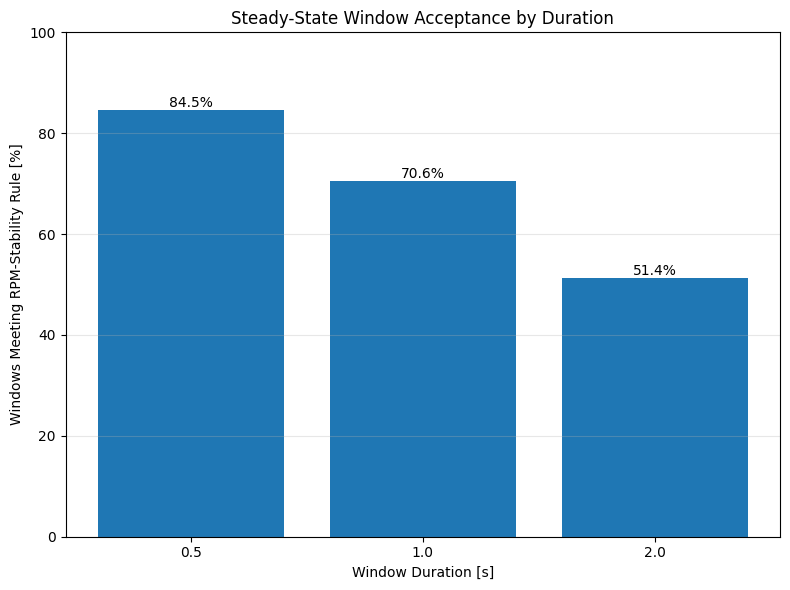

Saved: /content/engine-nvh-deep-learning/results/figures/preprocessing_design/01_steady_window_acceptance.png


In [10]:
# Plot steady-window acceptance
fig, ax = plt.subplots(figsize=(8, 6))

ax.bar(
    window_comparison["window_duration_s"].astype(str),
    100 * window_comparison["steady_fraction"],
)

ax.set_title("Steady-State Window Acceptance by Duration")
ax.set_xlabel("Window Duration [s]")
ax.set_ylabel("Windows Meeting RPM-Stability Rule [%]")
ax.set_ylim(0, 100)
ax.grid(True, axis="y", alpha=0.3)

for index, value in enumerate(
    100 * window_comparison["steady_fraction"]
):
    ax.text(
        index,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
    )

fig.tight_layout()

output_path = (
    DESIGN_FIGURE_DIR
    / "01_steady_window_acceptance.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Saved: {output_path}")

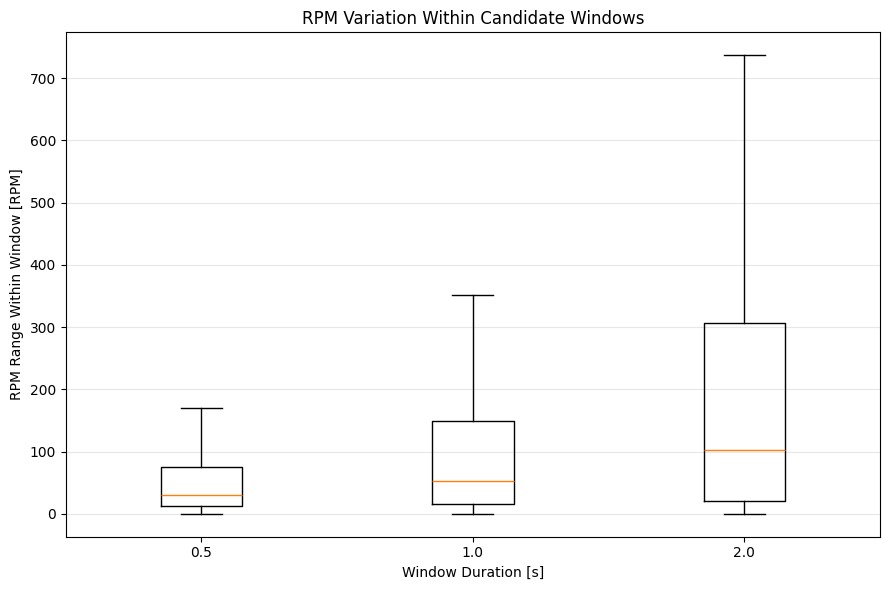

In [11]:
# Plot RPM range by Window duration
fig, ax = plt.subplots(figsize=(9, 6))

plot_groups = [
    window_candidates.loc[
        window_candidates["window_duration_s"] == duration,
        "rpm_range",
    ].dropna()
    for duration in CANDIDATE_WINDOW_DURATIONS_S
]

ax.boxplot(
    plot_groups,
    tick_labels=[
        str(duration)
        for duration in CANDIDATE_WINDOW_DURATIONS_S
    ],
    showfliers=False,
)

ax.set_title("RPM Variation Within Candidate Windows")
ax.set_xlabel("Window Duration [s]")
ax.set_ylabel("RPM Range Within Window [RPM]")
ax.grid(True, axis="y", alpha=0.3)

fig.tight_layout()

output_path = (
    DESIGN_FIGURE_DIR
    / "02_rpm_variation_by_window_duration.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)


Decision rule

Using this initial decision logic:

* Choose 1.0 second when at least approximately 70% of the windows pass the RPM-stability rule.
* Choose 0.5 second when one-second windows reject an excessive portion of the data.
* Choose 2.0 seconds only when RPM remains highly stable and the additional spectral resolution is clearly useful.

Current recommended default is:
*   Window duration: 1.0 second
*   Overlap: 50%



In [14]:
# Step 4 — Evaluate the two audio channels

# Before averaging left and right audio, check whether they are similar enough.
# Selecting representative files across the dataset

sample_indices = np.linspace(
    0,
    len(raw_manifest) - 1,
    30,
    dtype=int,
)

channel_records = []

for index in sample_indices:
    row = raw_manifest.iloc[index]
    wav_path = RAW_ROOT / row["relative_file_path"]

    signal, sample_rate = sf.read(
        wav_path,
        always_2d=True,
    )

    left = signal[:, 0]
    right = signal[:, 1]

    left_std = np.std(left)
    right_std = np.std(right)

    if left_std > 0 and right_std > 0:
        correlation = float(
            np.corrcoef(left, right)[0, 1]
        )
    else:
        correlation = np.nan

    left_rms = np.sqrt(np.mean(left**2))
    right_rms = np.sqrt(np.mean(right**2))

    level_difference_db = 20 * np.log10(
        max(left_rms, 1e-12)
        / max(right_rms, 1e-12)
    )

    channel_records.append(
        {
            "file_id": row["file_id"],
            "left_right_correlation": correlation,
            "left_right_level_difference_db": (
                level_difference_db
            ),
        }
    )

channel_analysis = pd.DataFrame(channel_records)

display(channel_analysis.describe())

# Summarize
median_correlation = (
    channel_analysis["left_right_correlation"].median()
)

median_abs_level_difference = (
    channel_analysis[
        "left_right_level_difference_db"
    ]
    .abs()
    .median()
)

print(
    f"Median left-right correlation: "
    f"{median_correlation:.3f}"
)

print(
    f"Median absolute level difference: "
    f"{median_abs_level_difference:.2f} dB"
)

,left_right_correlation,left_right_level_difference_db
count,3.000000e+01,3.000000e+01
mean,1.000000e+00,8.105029e-07
std,1.544967e-08,8.914149e-06
min,9.999999e-01,-1.799298e-05
25%,1.000000e+00,-1.969139e-06
50%,1.000000e+00,0.000000e+00
75%,1.000000e+00,3.195345e-06
max,1.000000e+00,2.515576e-05


Median left-right correlation: 1.000
Median absolute level difference: 0.00 dB


Use this decision guidance:

Observation	Initial strategy
High correlation and small level difference	Average left and right to mono
Low correlation or evidence of cancellation	Use left channel only for PREP-001
Stereo differences appear physically useful	Preserve two channels for a later ablation model

For the first model, the preferred strategy is:
mono_average = (left + right) / 2

unless the channel comparison reveals substantial cancellation or major differences.

Do not normalize each window to the same RMS level. Per-window RMS normalization could remove amplitude information related to torque.

Use:
Amplitude normalization: none at preprocessing stage

Later, global feature standardization should be fitted using the training set only.

In [5]:
# Step 5 — Verify the proposed 16 kHz sample rate

# The original signals are 48 kHz. The proposed model sample rate is 16 kHz,
# giving an 8 kHz Nyquist frequency.
# For the first model, 16 kHz is acceptable when:
  # Your target orders fall comfortably below 8 kHz.
  # You are willing to limit the audio representation to the 0–8 kHz band.
  # High-frequency exhaust or mechanical details above 8 kHz are not required.
# The raw 48 kHz files remain unchanged. Only model input windows are resampled.

# Calculate the highest expected order frequency
maximum_dataset_rpm = float(
    raw_manifest["rpm_max"].max()
)

candidate_orders = [1, 2, 4, 6, 8]

order_frequency_table = pd.DataFrame(
    {
        "order": candidate_orders,
        "maximum_frequency_hz": [
            order
            * maximum_dataset_rpm
            / 60
            for order in candidate_orders
        ],
    }
)

print(f"Maximum dataset RPM: {maximum_dataset_rpm:.1f}")
display(order_frequency_table)

Maximum dataset RPM: 7007.4


,order,maximum_frequency_hz
0,1,116.790771
1,2,233.581543
2,4,467.163086
3,6,700.744629
4,8,934.326172


In [6]:
# Check the margin relative to the 8 kHz Nyquist frequency
TARGET_SAMPLE_RATE_HZ = 16_000
NYQUIST_FREQUENCY_HZ = TARGET_SAMPLE_RATE_HZ / 2

order_frequency_table["fraction_of_nyquist"] = (
    order_frequency_table["maximum_frequency_hz"]
    / NYQUIST_FREQUENCY_HZ
)

display(order_frequency_table)

,order,maximum_frequency_hz,fraction_of_nyquist
0,1,116.790771,0.014599
1,2,233.581543,0.029198
2,4,467.163086,0.058395
3,6,700.744629,0.087593
4,8,934.326172,0.116791


In [7]:
# Code the calculations so the target definitions are reproducible and not
# manually estimated.
# At this stage, the purpose is to take the candidate windowing logic already
# built and, for the chosen PREP-001 window definition, calculate the
# exact RPM and torque statistics that will later become
# labels in sample_manifest_v001.csv.

# Candidate window duration to be frozen
  # Window duration = 1.0 s
  # Overlap = 50%
  # Primary RPM target = rpm_mean
  # Secondary torque target = torque_mean_nm

# Recompute the chosen PREP-001 windows with all target statistics
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import soundfile as sf

# ------------------------------------------------------------
# PREP-001 target-definition settings
# ------------------------------------------------------------

WINDOW_DURATION_S = 1.0
OVERLAP_FRACTION = 0.50

prep001_records = []

for row in tqdm(
    raw_manifest.itertuples(index=False),
    total=len(raw_manifest),
):
    wav_path = RAW_ROOT / row.relative_file_path

    signal, sample_rate = sf.read(
        wav_path,
        always_2d=True,
    )

    # Confirm expected dataset structure
    if signal.shape[1] != 4:
        continue

    # Recover physical annotation channels
    rpm_trace = signal[:, 2] * 10_000
    torque_trace_nm = signal[:, 3] * 1_000

    # Window definition
    window_samples = round(
        WINDOW_DURATION_S * sample_rate
    )

    hop_samples = round(
        window_samples * (1 - OVERLAP_FRACTION)
    )

    if len(signal) < window_samples:
        continue

    starts = range(
        0,
        len(signal) - window_samples + 1,
        hop_samples,
    )

    for window_index, start_sample in enumerate(starts):

        end_sample = start_sample + window_samples

        rpm_window = rpm_trace[
            start_sample:end_sample
        ]

        torque_window = torque_trace_nm[
            start_sample:end_sample
        ]

        # ----------------------------------------------------
        # RPM statistics
        # ----------------------------------------------------

        rpm_mean = float(np.mean(rpm_window))
        rpm_median = float(np.median(rpm_window))
        rpm_min = float(np.min(rpm_window))
        rpm_max = float(np.max(rpm_window))
        rpm_std = float(np.std(rpm_window))
        rpm_range = rpm_max - rpm_min

        # ----------------------------------------------------
        # Torque statistics
        # ----------------------------------------------------

        torque_mean = float(
            np.mean(torque_window)
        )

        torque_median = float(
            np.median(torque_window)
        )

        torque_min = float(
            np.min(torque_window)
        )

        torque_max = float(
            np.max(torque_window)
        )

        torque_std = float(
            np.std(torque_window)
        )

        torque_range = (
            torque_max - torque_min
        )

        prep001_records.append(
            {
                "file_id": row.file_id,
                "window_index": window_index,

                "start_time_s":
                    start_sample / sample_rate,

                "end_time_s":
                    end_sample / sample_rate,

                "rpm_mean": rpm_mean,
                "rpm_median": rpm_median,
                "rpm_min": rpm_min,
                "rpm_max": rpm_max,
                "rpm_std": rpm_std,
                "rpm_range": rpm_range,

                "torque_mean_nm":
                    torque_mean,

                "torque_median_nm":
                    torque_median,

                "torque_min_nm":
                    torque_min,

                "torque_max_nm":
                    torque_max,

                "torque_std_nm":
                    torque_std,

                "torque_range_nm":
                    torque_range,
            }
        )

prep001_targets = pd.DataFrame(
    prep001_records
)

print(
    f"PREP-001 candidate windows: "
    f"{len(prep001_targets)}"
)

display(prep001_targets.head())

  0%|          | 0/767 [00:00<?, ?it/s]

PREP-001 candidate windows: 16503


,file_id,window_index,start_time_s,end_time_s,rpm_mean,rpm_median,rpm_min,rpm_max,rpm_std,rpm_range,torque_mean_nm,torque_median_nm,torque_min_nm,torque_max_nm,torque_std_nm,torque_range_nm
0,A-0000,0,0.0,1.0,1886.532459,1886.596680,1834.716797,1934.204102,26.163200,99.487305,-24.545169,-24.444580,-26.519775,-22.918701,0.939696,3.601074
1,A-0000,1,0.5,1.5,1836.565132,1834.716797,1777.954102,1888.427734,31.635357,110.473633,-23.089305,-23.132324,-25.115967,-20.874023,0.964778,4.241943
2,A-0000,2,1.0,2.0,1781.221377,1778.564453,1722.412109,1834.716797,32.231863,112.304688,-21.539623,-21.270752,-23.254395,-19.775391,1.038085,3.479004
3,A-0000,3,1.5,2.5,1731.200104,1731.872559,1691.894531,1778.564453,28.183325,86.669922,-20.361546,-20.263672,-21.514893,-19.287109,0.551702,2.227783
4,A-0000,4,2.0,3.0,1686.320407,1692.199707,1640.625000,1737.365723,26.258392,96.740723,-19.267174,-19.287109,-20.751953,-17.364502,0.825930,3.387451


In [9]:
# Add the steady-state criterion

# Now calculate whether each window is sufficiently stable to justify
# using one scalar RPM target.
# The provisional rule we defined was: RPM range must be less than or equal
# to the greater of 100 RPM or 3% of the mean RPM.

ABSOLUTE_RPM_LIMIT = 100.0
RELATIVE_RPM_LIMIT = 0.03

prep001_targets[
    "allowed_rpm_range"
] = np.maximum(
    ABSOLUTE_RPM_LIMIT,
    RELATIVE_RPM_LIMIT
    * prep001_targets["rpm_mean"].abs(),
)

prep001_targets[
    "steady_v001"
] = (
    prep001_targets["rpm_range"]
    <=
    prep001_targets["allowed_rpm_range"]
)

prep001_targets[
    "operating_state"
] = np.where(
    prep001_targets["steady_v001"],
    "steady",
    "transient",
)

# now inspect the result
steady_counts = (
    prep001_targets[
        "operating_state"
    ]
    .value_counts()
)

display(steady_counts)

steady_fraction = (
    prep001_targets[
        "steady_v001"
    ]
    .mean()
)

print(
    f"Steady-state windows: "
    f"{100 * steady_fraction:.1f}%"
)

,count
operating_state,
steady,11646
transient,4857


Steady-state windows: 70.6%


In [11]:
# Check whether mean and median RPM agree

# This is important because we are proposing 'rpm_mean' as the model target
# If RPM varies asymmetrically within a window, the mean and median may diverge

prep001_targets[
    "rpm_mean_median_diff"
] = (
    prep001_targets["rpm_mean"]
    -
    prep001_targets["rpm_median"]
)

prep001_targets[
    "rpm_mean_median_abs_diff"
] = (
    prep001_targets[
        "rpm_mean_median_diff"
    ]
    .abs()
)

display(
    prep001_targets[
        "rpm_mean_median_abs_diff"
    ]
    .describe(
        percentiles=[
            0.50,
            0.90,
            0.95,
            0.99,
        ]
    )
)


# for steady-state windows specifically
# If the difference is typically very small for steady windows,
# that supports using 'rpm_mean'
steady_windows = prep001_targets.loc[
    prep001_targets["steady_v001"]
].copy()

display(
    steady_windows[
        "rpm_mean_median_abs_diff"
    ]
    .describe(
        percentiles=[
            0.50,
            0.90,
            0.95,
            0.99,
        ]
    )
)

,rpm_mean_median_abs_diff
count,16503.000000
mean,9.081360
std,50.034873
min,0.000000
50%,0.588303
90%,6.279233
95%,21.328518
99%,235.516497
max,980.955029


,rpm_mean_median_abs_diff
count,11646.000000
mean,0.736532
std,1.196916
min,0.000000
50%,0.345971
90%,1.801675
95%,2.600557
99%,5.602321
max,22.749602


In [12]:
# Check whether mean and median Torque agree
# Since torque will eventually be a second regression target,
# check mean versus median for torque as well

prep001_targets[
    "torque_mean_median_diff_nm"
] = (
    prep001_targets["torque_mean_nm"]
    -
    prep001_targets["torque_median_nm"]
)

prep001_targets[
    "torque_mean_median_abs_diff_nm"
] = (
    prep001_targets[
        "torque_mean_median_diff_nm"
    ]
    .abs()
)

display(
    steady_windows[
        [
            "torque_mean_nm",
            "torque_median_nm",
            "torque_range_nm",
            "torque_std_nm",
        ]
    ]
    .describe(
        percentiles=[
            0.50,
            0.90,
            0.95,
            0.99,
        ]
    )
)

display(
    prep001_targets[
        "torque_mean_median_abs_diff_nm"
    ]
    .describe(
        percentiles=[
            0.50,
            0.90,
            0.95,
            0.99,
        ]
    )
)

# At this stage, I would record torque variability but not reject samples
# based on torque stability yet.
# The first RPM model can use RPM stability as the inclusion criterion.


,torque_mean_nm,torque_median_nm,torque_range_nm,torque_std_nm
count,11646.000000,11646.000000,11646.000000,11646.000000
mean,106.027977,105.870090,7.577704,2.028440
std,173.614325,173.852632,32.833101,11.475559
min,-107.025146,-107.025146,0.000000,0.000000
50%,33.989676,33.050537,2.746582,0.590244
90%,338.722619,338.867188,11.322021,2.437324
95%,453.061084,453.063965,15.716553,3.510907
99%,693.101517,693.162537,100.292969,28.137516
max,704.066985,705.505371,812.225342,370.709254


,torque_mean_median_abs_diff_nm
count,16503.000000
mean,3.201905
std,14.510328
min,0.000000
50%,0.082027
90%,2.901683
95%,15.598716
99%,78.926682
max,278.803034


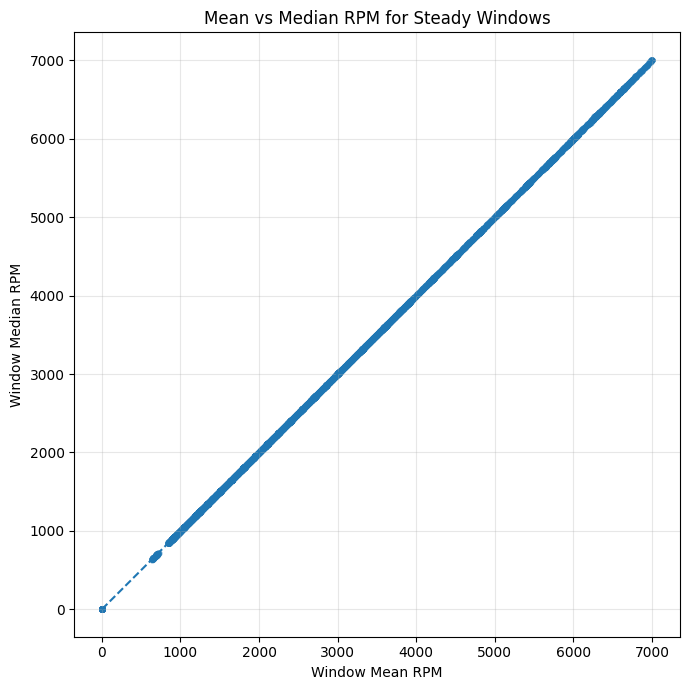

Saved: /content/engine-nvh-deep-learning/results/figures/preprocessing_design/03_rpm_mean_vs_median.png


In [15]:
# Plotting mean-vs-median RPM
# for a visual check that mean RPM is a sensible target

import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    figsize=(7, 7)
)

ax.scatter(
    steady_windows["rpm_mean"],
    steady_windows["rpm_median"],
    s=12,
    alpha=0.5,
)

minimum_value = min(
    steady_windows["rpm_mean"].min(),
    steady_windows["rpm_median"].min(),
)

maximum_value = max(
    steady_windows["rpm_mean"].max(),
    steady_windows["rpm_median"].max(),
)

ax.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    linewidth=1.5,
)

ax.set_xlabel("Window Mean RPM")
ax.set_ylabel("Window Median RPM")

ax.set_title(
    "Mean vs Median RPM for Steady Windows"
)

ax.grid(True, alpha=0.3)

fig.tight_layout()

output_path = (
    DESIGN_FIGURE_DIR
    / "03_rpm_mean_vs_median.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

print(f"Saved: {output_path}")

# If the points lie closely along the diagonal, rpm_mean is a
# very defensible label.

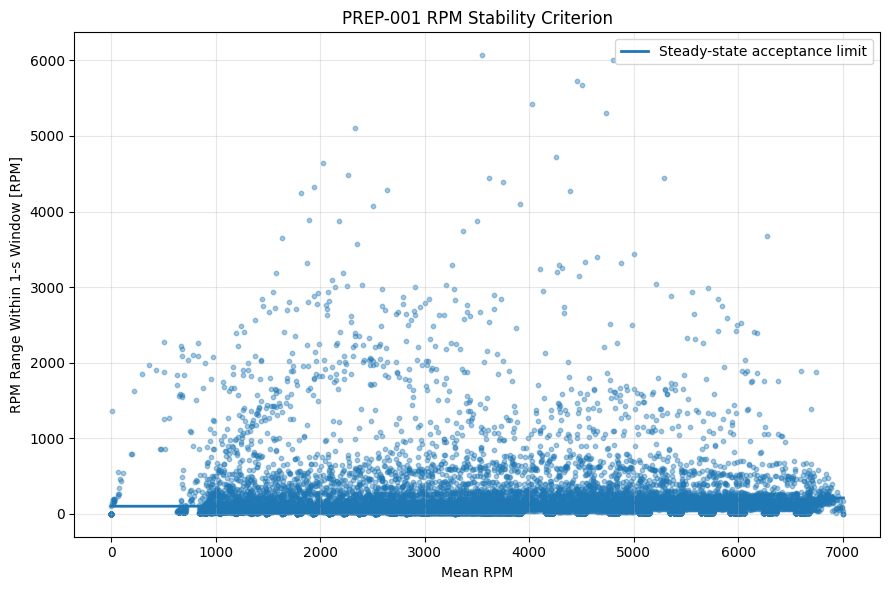

In [16]:
# Plot RPM variation against mean RPM
# This helps check whether the steady-state threshold behaves reasonably
# across the operating range.

fig, ax = plt.subplots(
    figsize=(9, 6)
)

ax.scatter(
    prep001_targets["rpm_mean"],
    prep001_targets["rpm_range"],
    s=10,
    alpha=0.4,
)

rpm_axis = np.linspace(
    prep001_targets["rpm_mean"].min(),
    prep001_targets["rpm_mean"].max(),
    500,
)

allowed_range_curve = np.maximum(
    ABSOLUTE_RPM_LIMIT,
    RELATIVE_RPM_LIMIT
    * np.abs(rpm_axis),
)

ax.plot(
    rpm_axis,
    allowed_range_curve,
    linewidth=2,
    label="Steady-state acceptance limit",
)

ax.set_xlabel("Mean RPM")
ax.set_ylabel("RPM Range Within 1-s Window [RPM]")

ax.set_title(
    "PREP-001 RPM Stability Criterion"
)

ax.grid(True, alpha=0.3)
ax.legend()

fig.tight_layout()

output_path = (
    DESIGN_FIGURE_DIR
    / "04_rpm_stability_criterion.png"
)

fig.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close(fig)

# This is a useful engineering figure because it shows exactly
# how you separated steady and transient samples.

In [17]:
# Calculate the actual target-definition summary

# Creating a compact table describing the proposed labels.
target_summary = pd.DataFrame(
    [
        {
            "target": "rpm_mean",
            "role": "primary",
            "population": "steady windows",
            "minimum": (
                steady_windows[
                    "rpm_mean"
                ].min()
            ),
            "maximum": (
                steady_windows[
                    "rpm_mean"
                ].max()
            ),
            "mean": (
                steady_windows[
                    "rpm_mean"
                ].mean()
            ),
            "std": (
                steady_windows[
                    "rpm_mean"
                ].std()
            ),
        },
        {
            "target": "torque_mean_nm",
            "role": "secondary",
            "population": "steady windows",
            "minimum": (
                steady_windows[
                    "torque_mean_nm"
                ].min()
            ),
            "maximum": (
                steady_windows[
                    "torque_mean_nm"
                ].max()
            ),
            "mean": (
                steady_windows[
                    "torque_mean_nm"
                ].mean()
            ),
            "std": (
                steady_windows[
                    "torque_mean_nm"
                ].std()
            ),
        },
    ]
)

display(target_summary)

# Save it
TARGET_SUMMARY_PATH = (
    DESIGN_TABLE_DIR
    / "target_definition_summary_v001.csv"
)

target_summary.to_csv(
    TARGET_SUMMARY_PATH,
    index=False,
)

print(
    f"Saved target summary:\n"
    f"{TARGET_SUMMARY_PATH}"
)

,target,role,population,minimum,maximum,mean,std
0,rpm_mean,primary,steady windows,0.000000,7007.446289,3054.069437,1732.633517
1,torque_mean_nm,secondary,steady windows,-107.025146,704.066985,106.027977,173.614325


Saved target summary:
/content/engine-nvh-deep-learning/results/tables/target_definition_summary_v001.csv


In [18]:
# Save the detailed PREP-001 design table to Google Drive

# The full window-level table may become large, so keep it in Drive
# rather than GitHub

PREP001_TARGET_ANALYSIS_PATH = (
    DRIVE_DESIGN_TABLE_DIR
    / "prep001_target_analysis_v001.csv.gz"
)

prep001_targets.to_csv(
    PREP001_TARGET_ANALYSIS_PATH,
    index=False,
    compression="gzip",
)

print(
    f"Saved detailed target analysis:\n"
    f"{PREP001_TARGET_ANALYSIS_PATH}"
)

# Why did we classify this particular window as transient?

Saved detailed target analysis:
/content/drive/MyDrive/NVH_DeepLearning/01_EngineOperatingState/outputs/tables/preprocessing_design/prep001_target_analysis_v001.csv.gz
